# Understand the Problem Statement and Business Case

The World Happiness Report clustering project applies unsupervised machine learning techniques to group countries based on factors that influence quality of life, such as economic production, social support, life expectancy, freedom, generosity, and corruption levels. By analyzing these indicators, the model identifies similarities among nations without using predefined labels, helping researchers better understand global happiness patterns. The happiness scores are collected through surveys in which individuals rate their lives on a scale from 0 (worst possible life) to 10 (best possible life). This type of clustering analysis is useful for discovering trends, comparing regions, and supporting public policies aimed at improving well-being and living conditions around the world.


# Import Datasets and Libraries

In [2]:
# Get the required dependencies
!pip install bubbly
!pip install iplot
!pip install chart_studio

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement iplot (from versions: none)
ERROR: No matching distribution found for iplot


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go
from chart_studio.plotly import plot, iplot
from plotly.offline import iplot

In [4]:
df = pd.read_csv('data/happiness_report.csv')

In [5]:
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [6]:
brazil = df[df['Country or region'] == 'Brazil']
brazil.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
31,32,Brazil,6.3,1.004,1.439,0.802,0.39,0.099,0.086


In [7]:
len(df)

156

# Perform Exploratory Data Analysis

In [8]:
# Check the number of non-null values in the dataframe
print(df.count())

Overall rank                    156
Country or region               156
Score                           156
GDP per capita                  156
Social support                  156
Healthy life expectancy         156
Freedom to make life choices    156
Generosity                      156
Perceptions of corruption       156
dtype: int64


In [9]:
# Check Null values
df.isnull().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [10]:
print(df.describe())

       Overall rank       Score  GDP per capita  Social support  \
count    156.000000  156.000000      156.000000      156.000000   
mean      78.500000    5.407096        0.905147        1.208814   
std       45.177428    1.113120        0.398389        0.299191   
min        1.000000    2.853000        0.000000        0.000000   
25%       39.750000    4.544500        0.602750        1.055750   
50%       78.500000    5.379500        0.960000        1.271500   
75%      117.250000    6.184500        1.232500        1.452500   
max      156.000000    7.769000        1.684000        1.624000   

       Healthy life expectancy  Freedom to make life choices  Generosity  \
count               156.000000                    156.000000  156.000000   
mean                  0.725244                      0.392571    0.184846   
std                   0.242124                      0.143289    0.095254   
min                   0.000000                      0.000000    0.000000   
25%             

In [11]:
# check the number of duplicated entries in the dataframe
print(df.duplicated().sum())
 # since there are no duplicates, no further action is required

0


In [12]:
# country with the highest score
df.loc[df['Score'].idxmax(), 'Country or region']

'Finland'

# Perform Data Visualization

<Figure size 2000x2000 with 0 Axes>

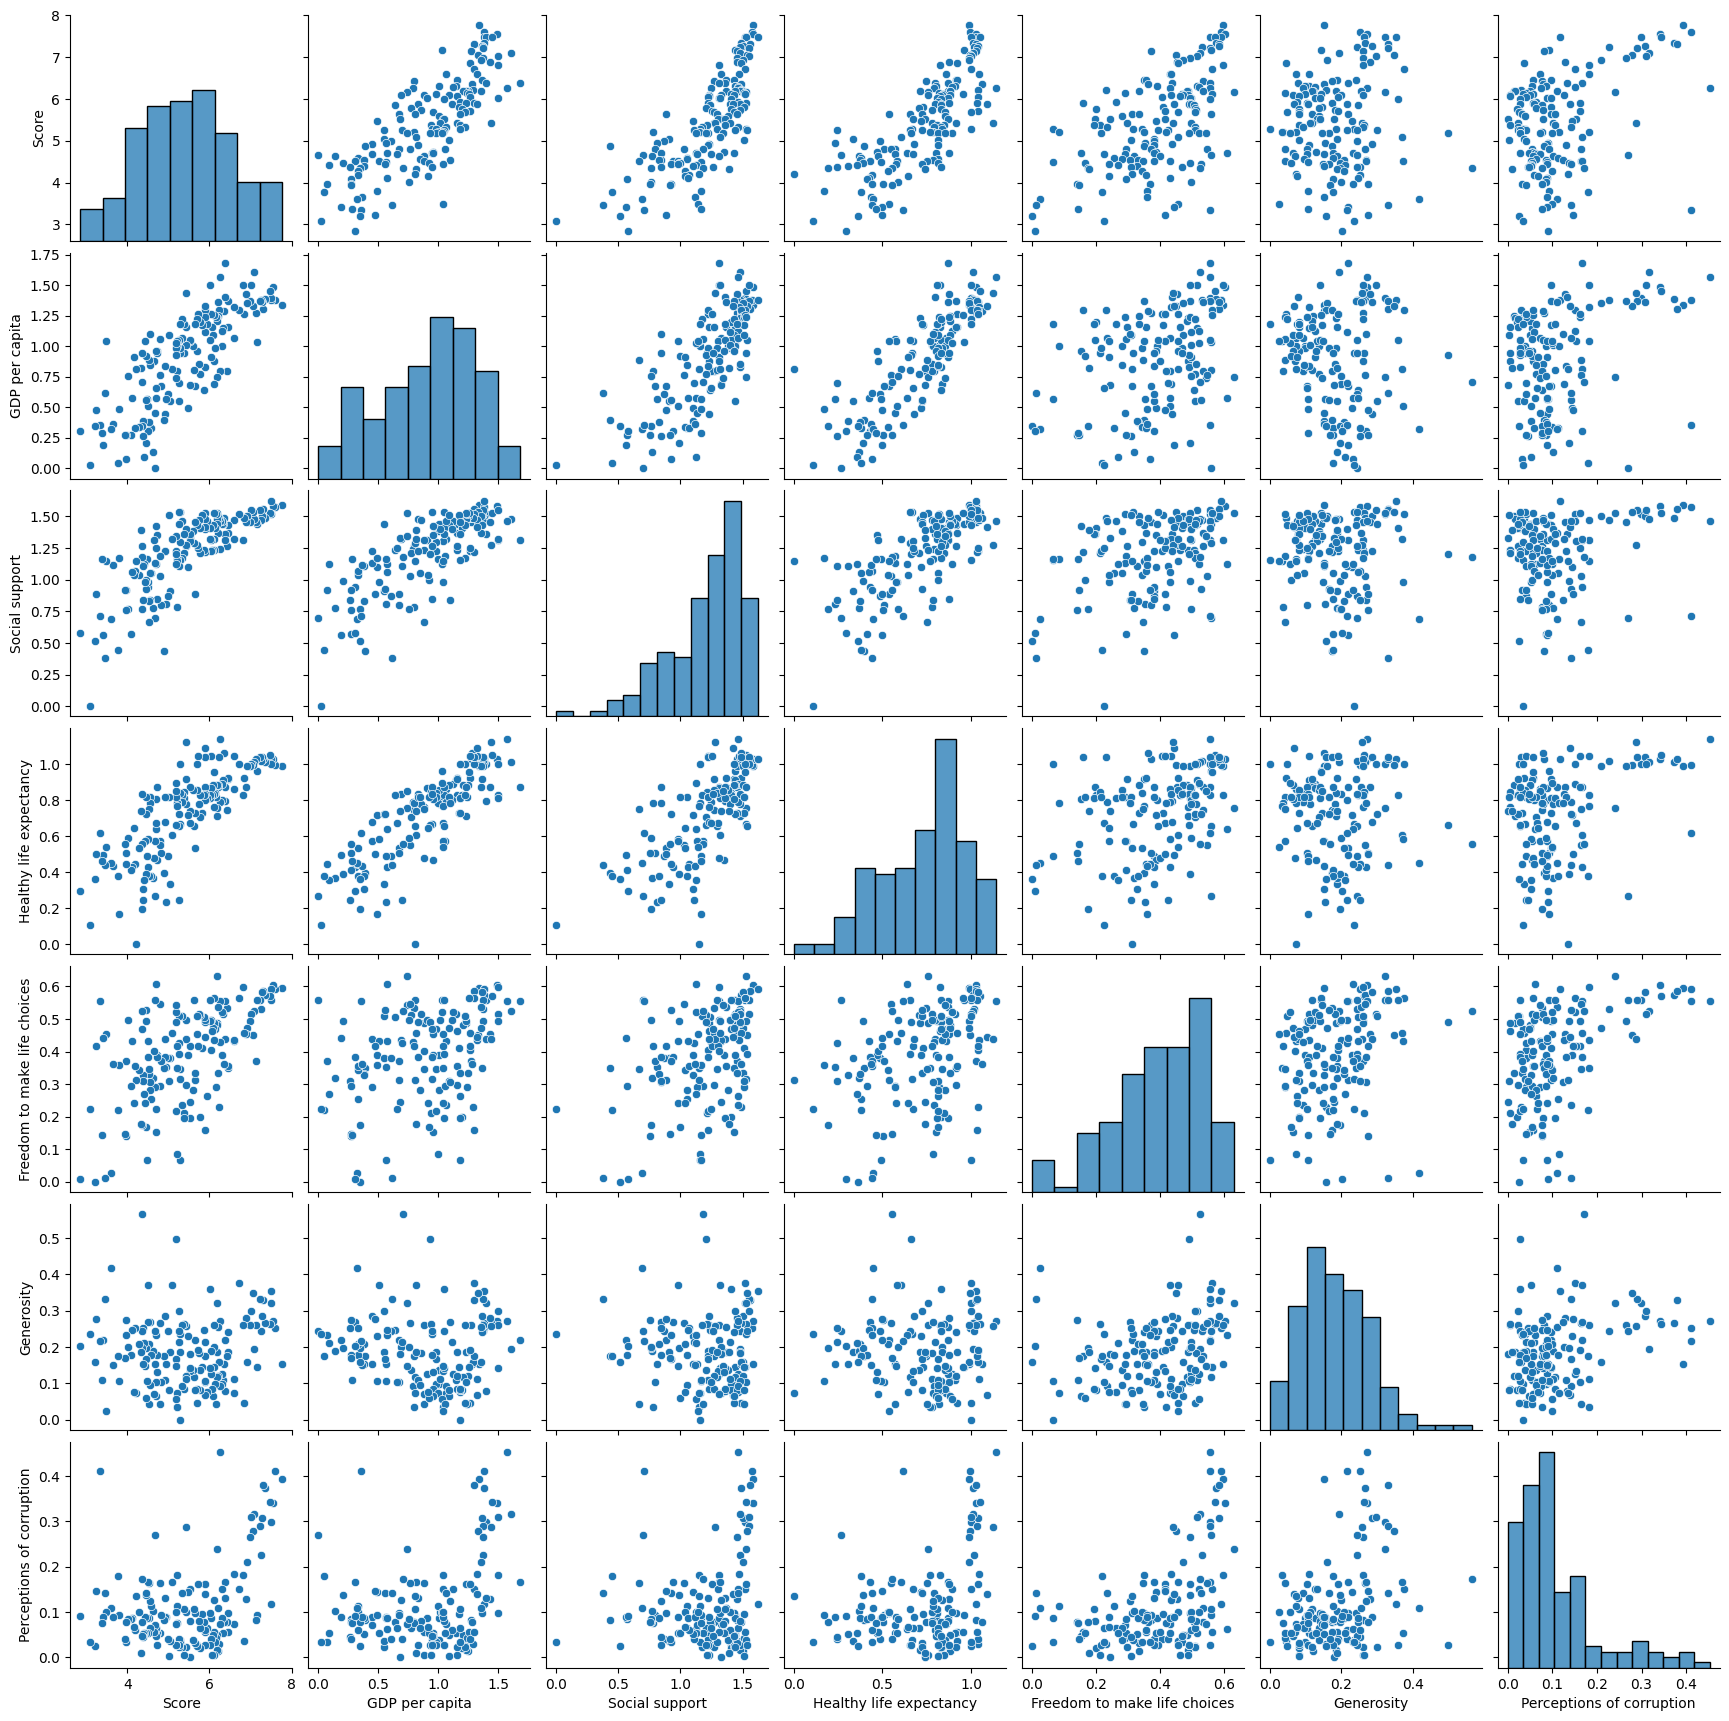

In [13]:
# Plot the pairplot
fig = plt.figure(figsize = (20,20))
sns.pairplot(df[['Score','GDP per capita', 'Social support', 'Healthy life expectancy', 
    'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption']])

# Positive correlation between GDP and score 
# Positive correlation between Social Support and score 

C:\Users\edmoc\AppData\Local\Temp\ipykernel_25436\1331739803.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[columns[i]], color = 'r');
C:\Users\edmoc\AppData\Local\Temp\ipykernel_25436\1331739803.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[columns[i]], color = 'r');
C:\Users\e

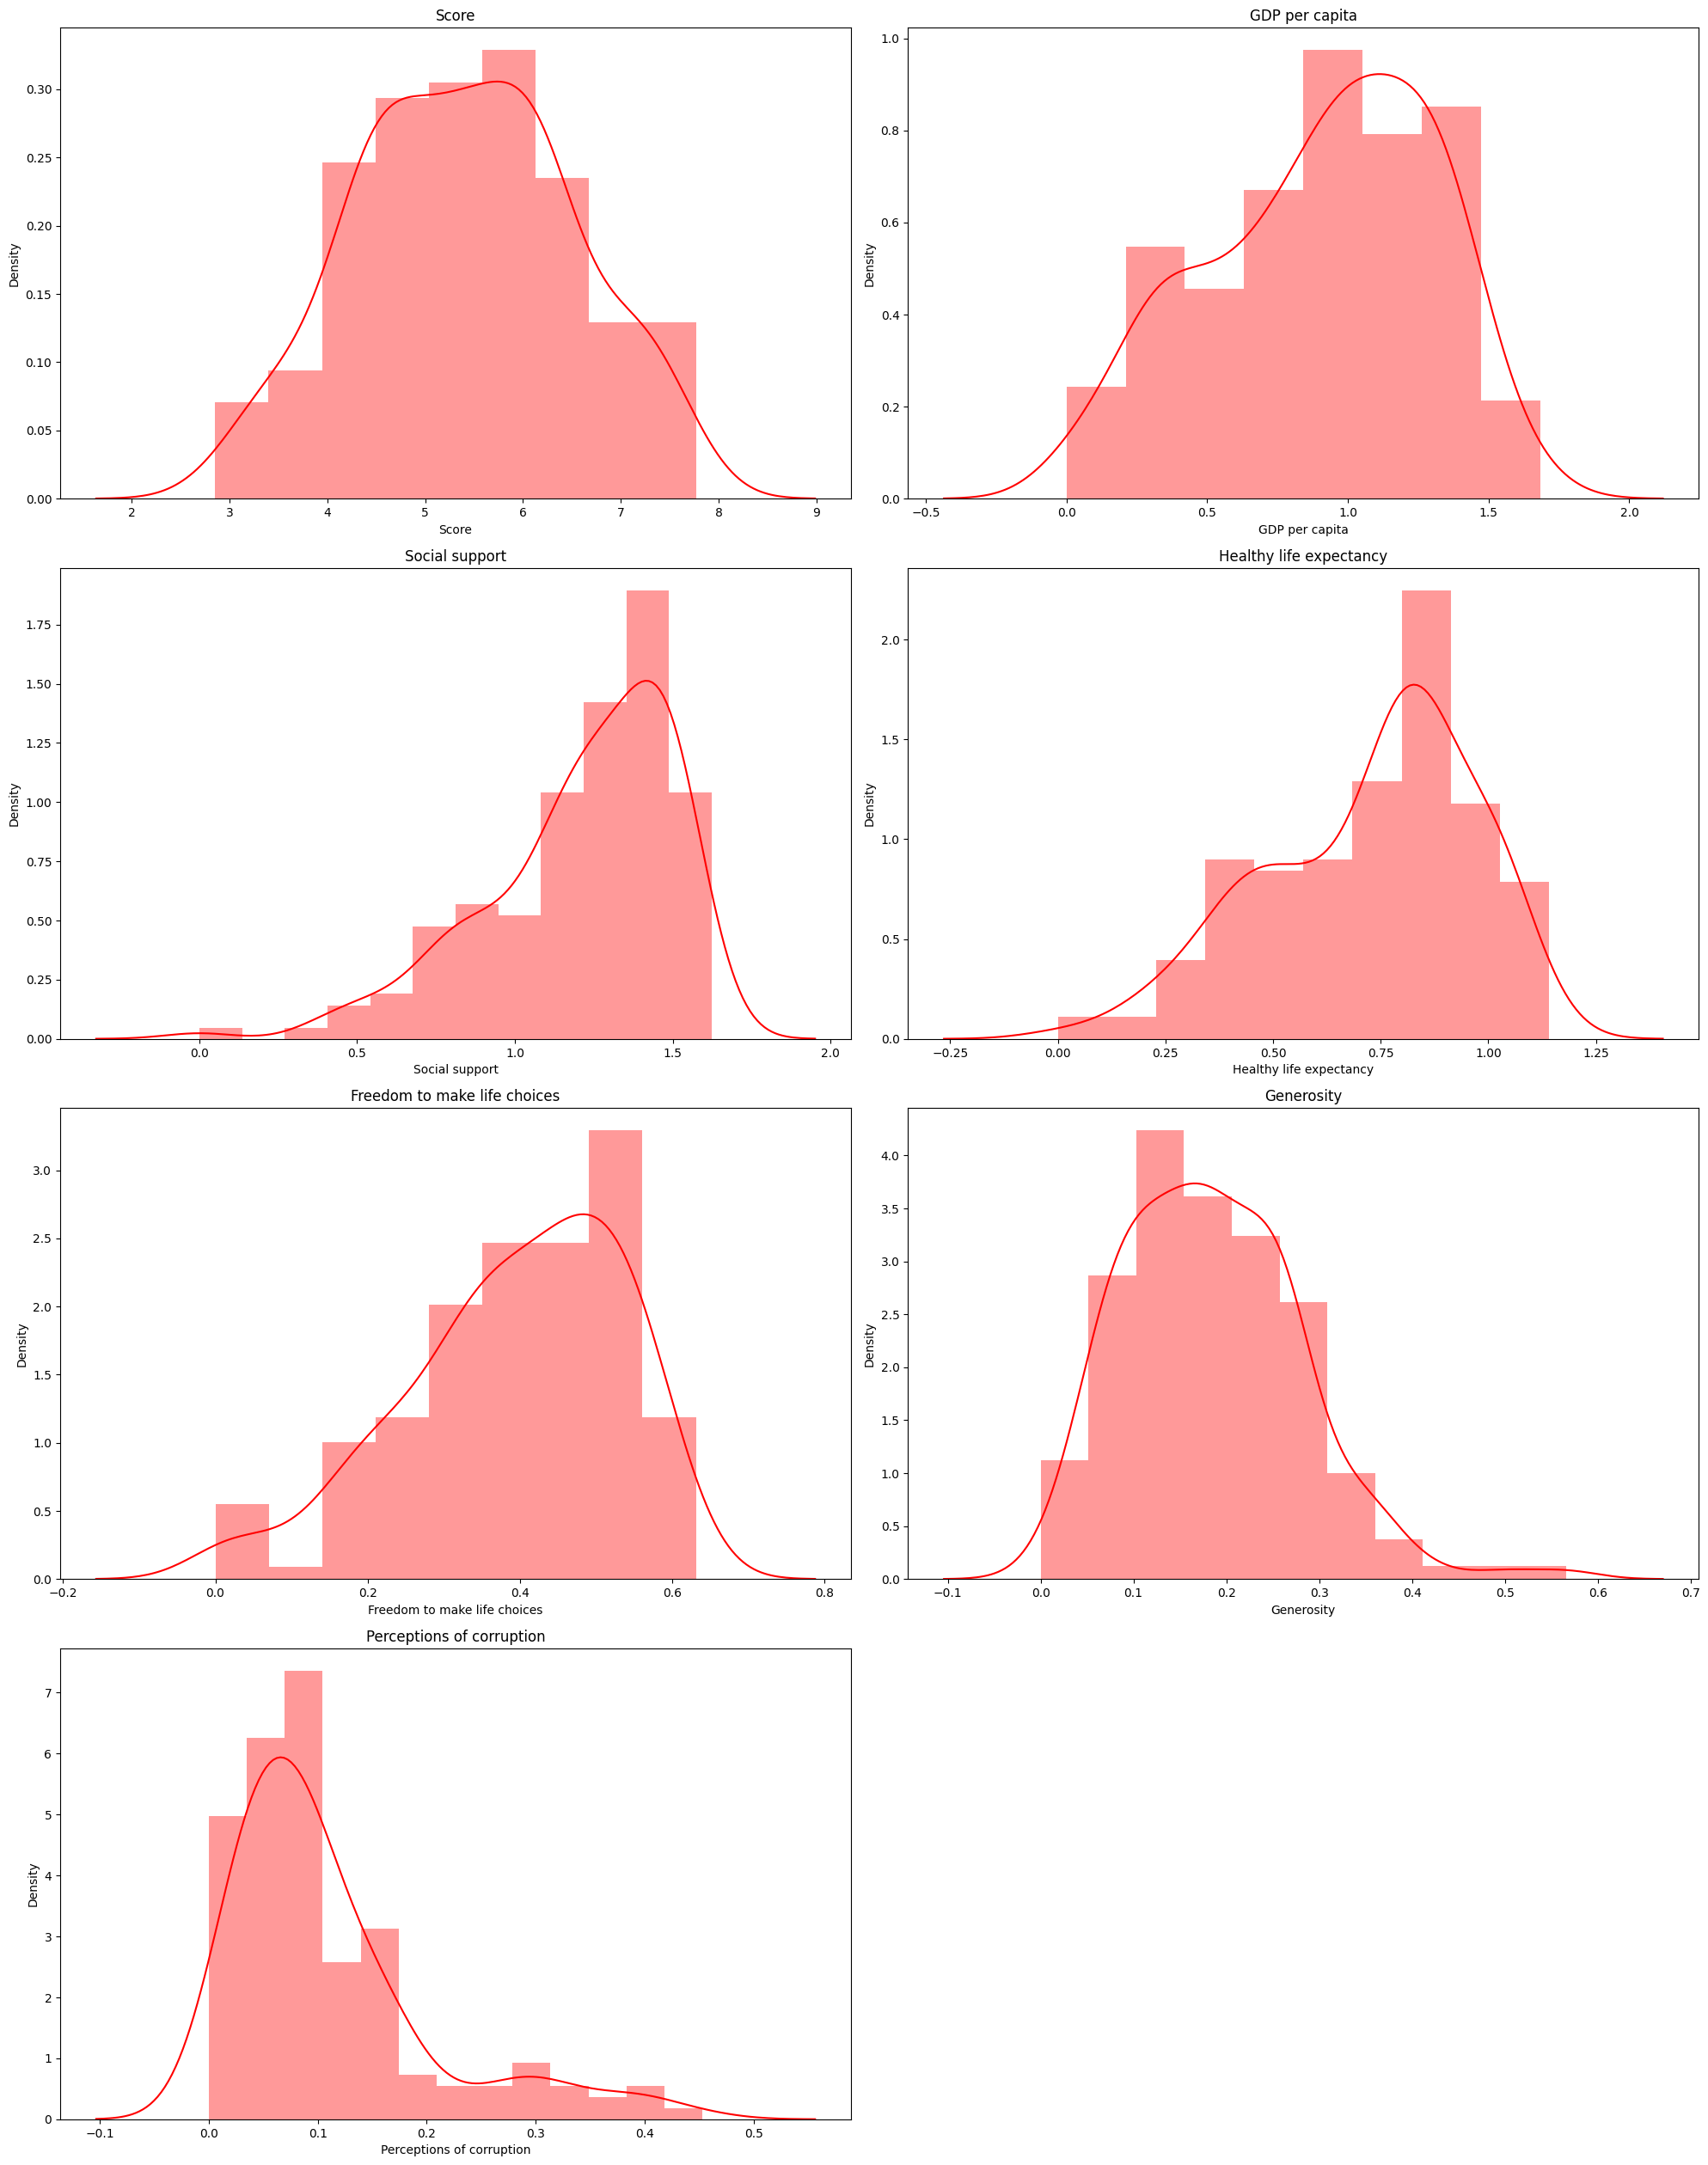

In [14]:
# distplot combines the matplotlib.hist function with seaborn kdeplot()
columns = ['Score','GDP per capita', 'Social support', 'Healthy life expectancy', 
    'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption']
plt.figure(figsize = (20, 50))
for i in range(len(columns)):
  plt.subplot(8, 2, i+1)
  sns.distplot(df[columns[i]], color = 'r');
  plt.title(columns[i])

plt.tight_layout()

Text(0.5, 1.0, 'Correlation Matrix')

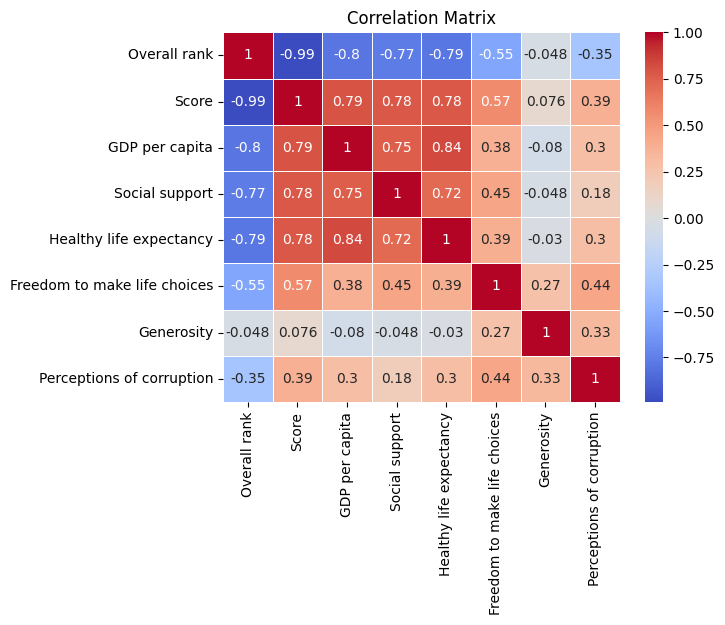

In [ ]:
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')

In [16]:
# Plot the relationship between score, GDP and region
fig = px.scatter(df,
                 x='GDP per capita',
                 y ='Score',
                 text = 'Country or region')
fig.show()

In [17]:
# Plot the relationship between score and GDP (while adding color and size)
fig = px.scatter(df,
                 x='GDP per capita',
                 y ='Score',
                 text = 'Country or region',
                 size='Overall rank',
                 color='Country or region')
fig.update_layout(title_text = 'Happiness Score vs GDP per Capita')
fig.show()

In [18]:
# Plot the relationship between score and healthy life expectancy
fig = px.scatter(df,
                x = 'Healthy life expectancy',
                y = "Score",
                size='Overall rank',
                color = "Country or region",
                hover_name = "Country or region",   
                text = 'Country or region',
                trendline="ols")
fig.update_traces (textposition = 'top center')
fig.update_layout (title_text = 'Happiness Score vs Healthy life expectancy')
fig.show()

In [19]:
# Plot the relationship between score and freedom to make life choices

fig = px.scatter(df,
                 x = 'Freedom to make life choices',
                 y = "Score", size = 'Overall rank',
                 color = "Country or region",
                 hover_name = "Country or region",
                 text = 'Country or region',
                 trendline = "ols")
fig.update_layout(title_text = 'Happiness Score vs Freedom to make life choices')
fig.show()

# Prepare the Data to Feed the Clustering Model

In [20]:
# We are going to create clusters without the use of happiness score and rank to see which countries fall under similar clusters
df.drop(['Score', 'Overall rank'], axis=1)

,Country or region,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Finland,1.340,1.587,0.986,0.596,0.153,0.393
1,Denmark,1.383,1.573,0.996,0.592,0.252,0.410
2,Norway,1.488,1.582,1.028,0.603,0.271,0.341
3,Iceland,1.380,1.624,1.026,0.591,0.354,0.118
4,Netherlands,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...
151,Rwanda,0.359,0.711,0.614,0.555,0.217,0.411
152,Tanzania,0.476,0.885,0.499,0.417,0.276,0.147
153,Afghanistan,0.350,0.517,0.361,0.000,0.158,0.025
154,Central African Republic,0.026,0.000,0.105,0.225,0.235,0.035


In [21]:
# Select the data without rank and happiness score
X = df.drop(['Overall rank', 'Score'], axis=1)

In [22]:
# Select the data without rank and happiness score
df_seg = df.drop(columns = ['Overall rank', 'Country or region', 'Score'])
df_seg

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1.340,1.587,0.986,0.596,0.153,0.393
1,1.383,1.573,0.996,0.592,0.252,0.410
2,1.488,1.582,1.028,0.603,0.271,0.341
3,1.380,1.624,1.026,0.591,0.354,0.118
4,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...
151,0.359,0.711,0.614,0.555,0.217,0.411
152,0.476,0.885,0.499,0.417,0.276,0.147
153,0.350,0.517,0.361,0.000,0.158,0.025
154,0.026,0.000,0.105,0.225,0.235,0.035


In [23]:
# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_seg)

In [24]:
scaled_data.shape

(156, 6)

# Understand the Intuition Behind K-Means 

The K-Means method is an unsupervised machine learning algorithm used to divide data into groups called clusters.

The algorithm creates exactly K clusters, where K is chosen beforehand.

## Choose Number of Clusters "k": Elbow Method 

The method uses WCSS (Within-Cluster Sum of Squares), which measures how compact the clusters are. Lower WCSS means better clustering. The optimization objective is:

\begin{equation}
J = \sum_{i=1}^{k} \sum_{x \in C_i} {\Vert x - \mu_i \Vert}^2
\end{equation}

where:

$k$ = number of clusters
$C_i$ = cluster i
$\mu_i$ = centroid of cluster i

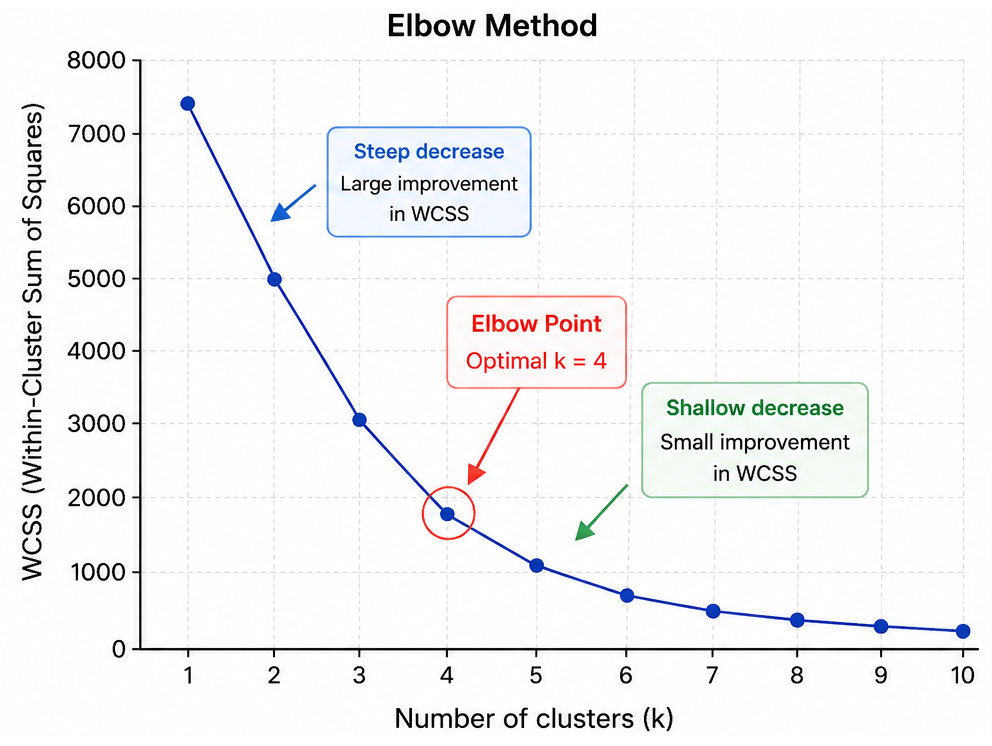

In [55]:
from IPython.display import Image
Image(filename='images/elbow-method.png', width=500) 

K-means algorithm steps:
1. Choose number of clusters "k".
2. Select random K points that are going to be the centroids for each cluster.
3. Assign each data point to the nearest centroid, doing so will enable us to create "k" number of clusters.

\begin{equation}
d(x,y)=\sqrt{\sum_{i=1}^{n}(x_i - \mu_i)^2}
\end{equation}

4. Calculate a new centroid for each cluster

\begin{equation}
\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x
\end{equation}

5. Reassign each data point to the new closest centroid
6. Go to step 4 and repeat.

# Find The Optimal Number Of Clusters

https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

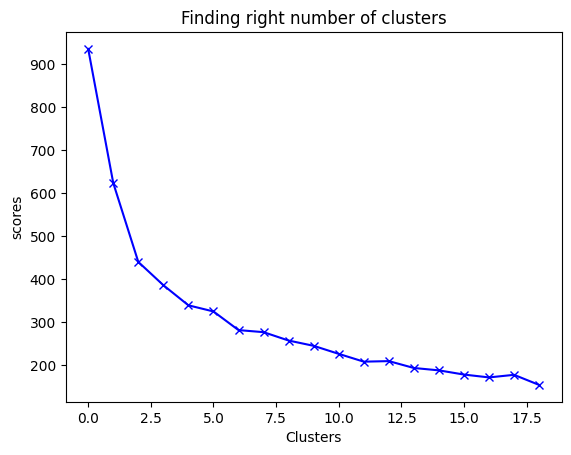

In [25]:
scores = []

range_values = range(1,20)
for i in range_values:
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(scaled_data)
    scores.append(kmeans.inertia_)

plt.plot(scores, 'bx-')
plt.title('Finding right number of clusters')
plt.xlabel('Clusters')
plt.ylabel('scores') 
plt.show()

From this we can observe that 3rd cluster seems to be forming the elbow of the curve. 
Let's choose the number of clusters to be 3.

# Perform Clustering Using K-Means

In [26]:
kmeans = KMeans(3)
kmeans.fit(scaled_data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [27]:
labels = kmeans.labels_

In [28]:
kmeans.cluster_centers_.shape

(3, 6)

In [29]:
cluster_centers = pd.DataFrame(data = kmeans.cluster_centers_, columns = [df_seg.columns])
cluster_centers    

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,0.352843,0.352013,0.393414,-0.076960,-0.527645,-0.442631
1,1.107826,0.880040,0.948949,1.053480,1.096544,1.649053
2,-1.235946,-1.108470,-1.219703,-0.446867,0.325199,-0.130575


In [30]:
# In order to understand what these numbers mean, let's perform inverse transformation
cluster_centers = scaler.inverse_transform(cluster_centers)
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [df_seg.columns])
cluster_centers

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1.045265,1.313795,0.820193,0.381578,0.134747,0.068892
1,1.345077,1.471269,0.954269,0.543038,0.288962,0.266000
2,0.414340,0.878234,0.430872,0.328745,0.215723,0.098298


- Cluster 0: countries that have GDP in the range of 0.6 to 1.4 and have high social support. These countries have medium life expectancy and have high freedom to make life choices. These counties have low generosity and low perception of corruption.
- Cluster 1: countries that have very high GDP, high social support and high life expectancy. These counties have high freedom to make life choices, medium generosity and medium perception of corruption.
- Cluster 2: countries that have low GDP average life expectancy and average social support. These counties have low freedom to make life choices, high generosity and medium perception of corruption.

In [31]:
labels.shape # Labels associated to each data point

(156,)

In [32]:
labels.max()

np.int32(2)

In [33]:
labels.min()

np.int32(0)

In [34]:
y_kmeans = kmeans.fit_predict(scaled_data)
y_kmeans

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 0, 0, 0, 2, 0,
       2, 2, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 1, 2,
       0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

In [35]:
# concatenate the clusters labels to our original dataframe
df_cluster = pd.concat([df, pd.DataFrame({'cluster':labels})], axis = 1)
df_cluster

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,cluster
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,1
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,1
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,1
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,1
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,1
...,...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411,2
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147,2
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025,2
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035,2


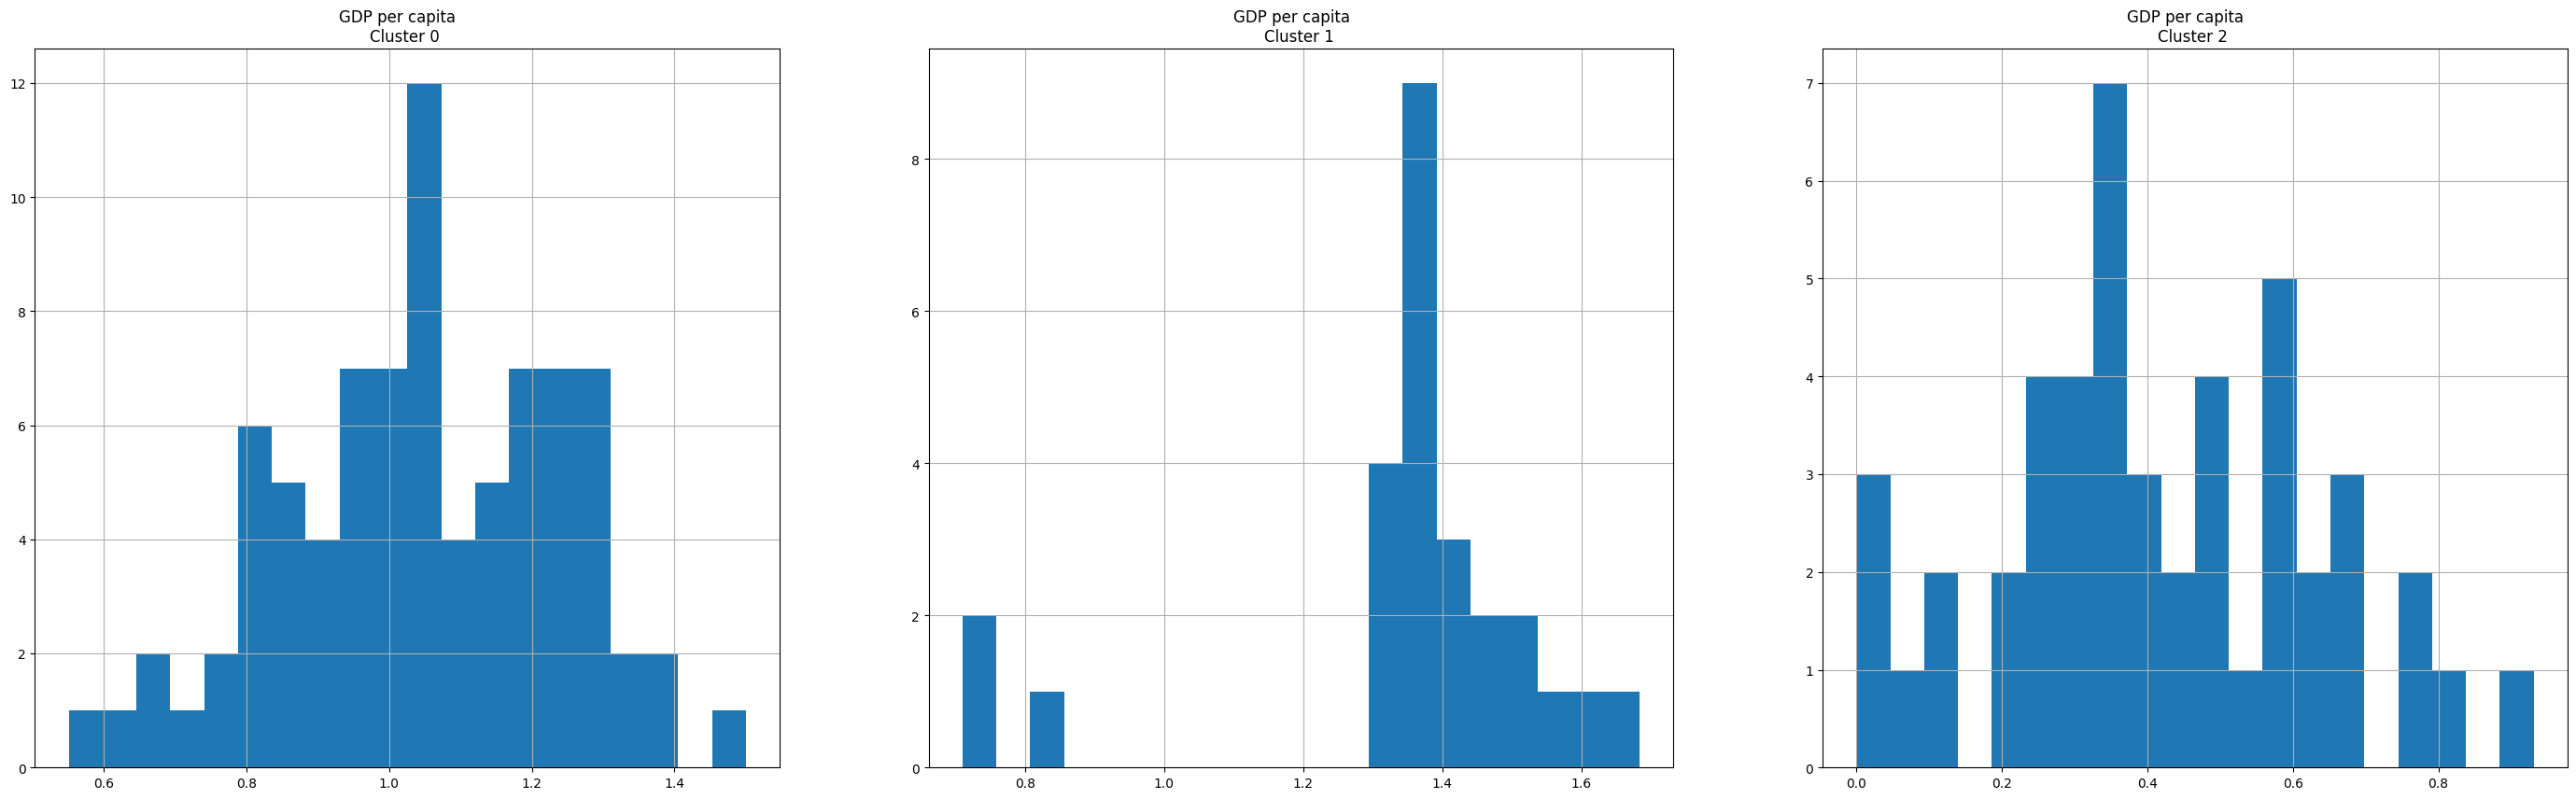

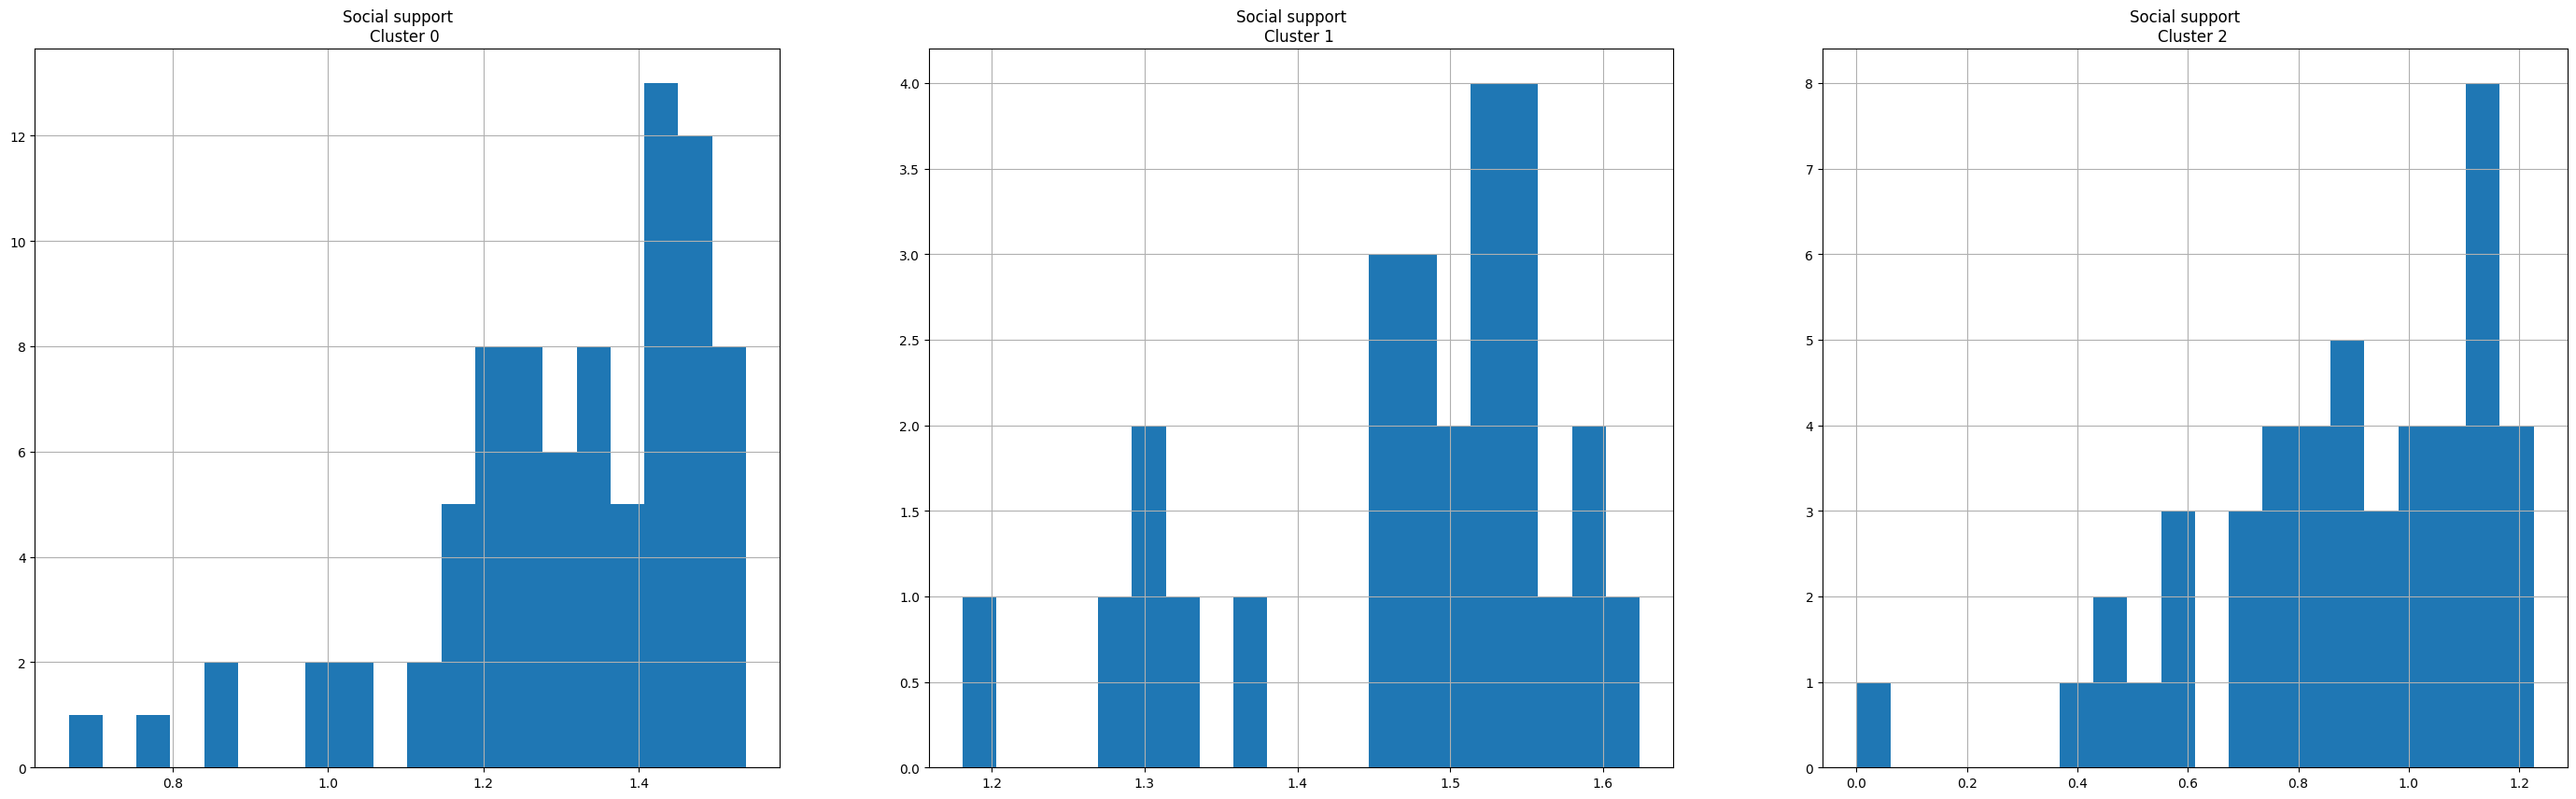

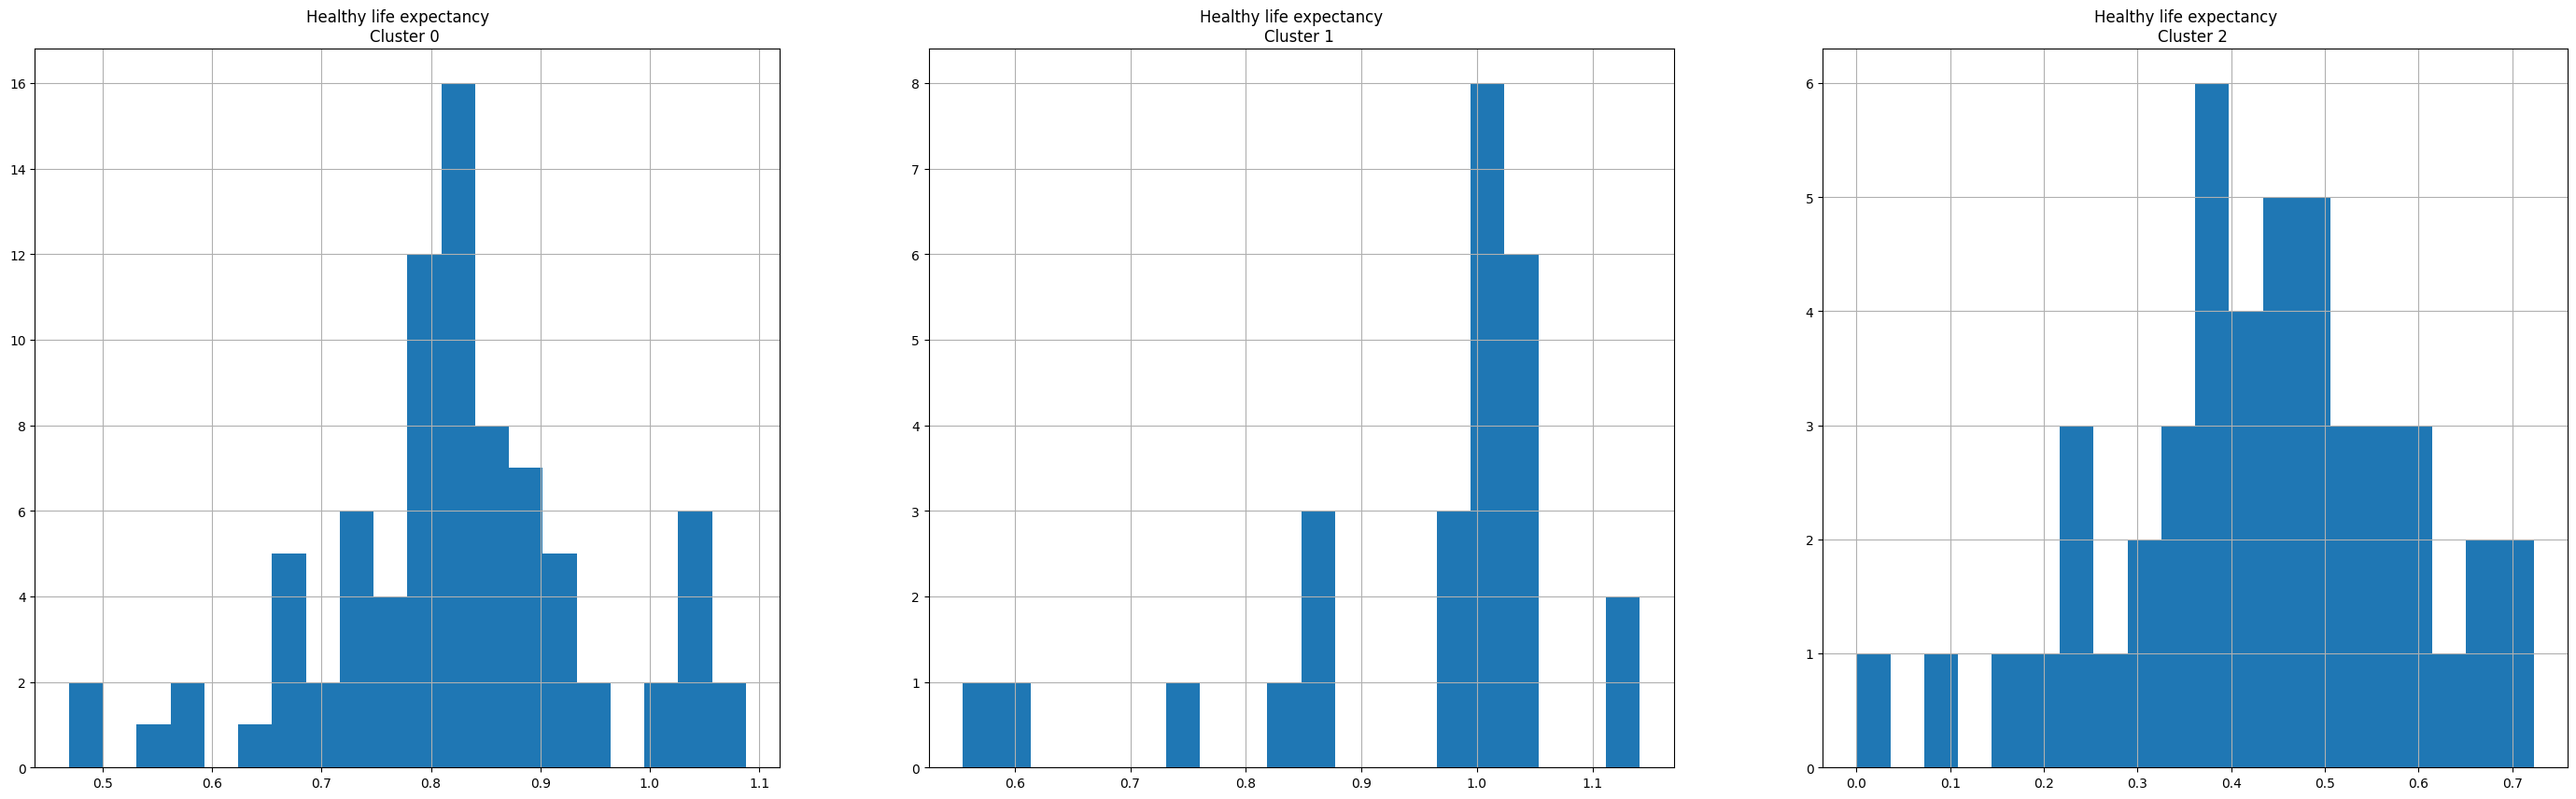

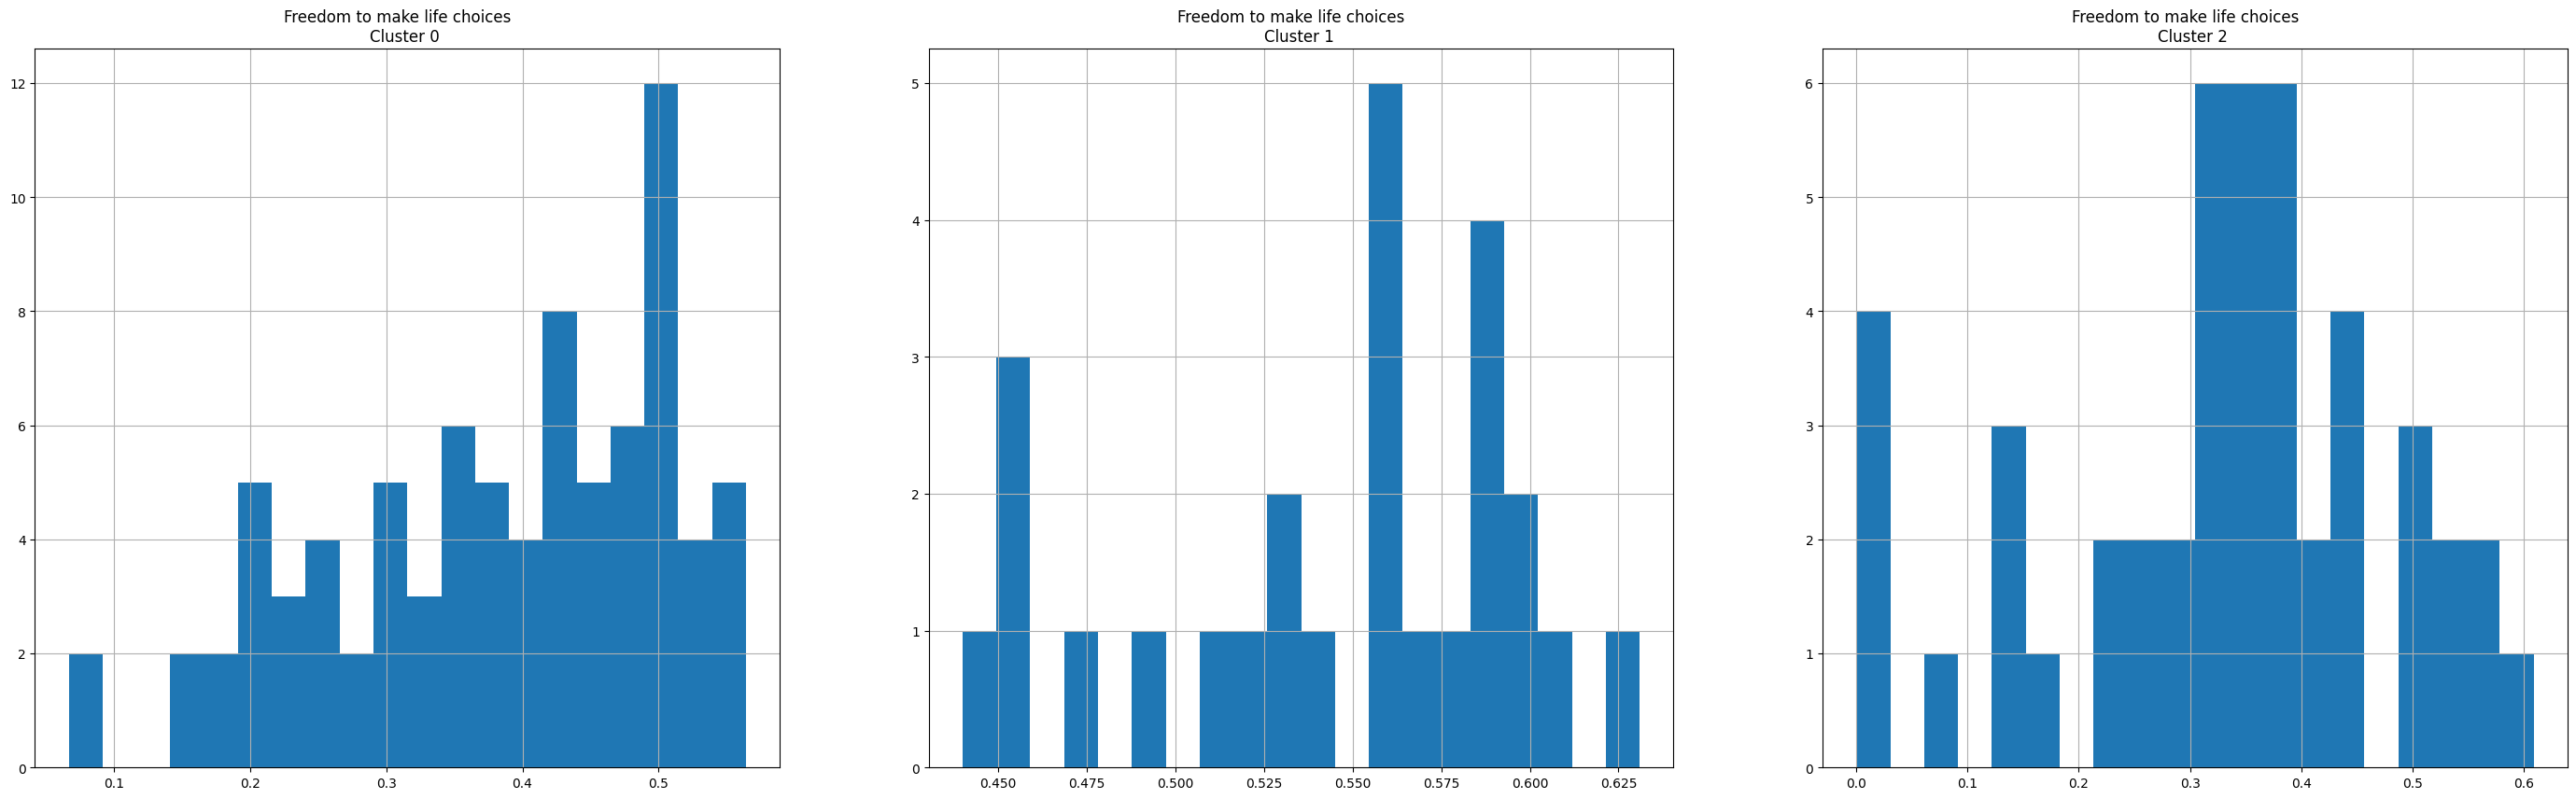

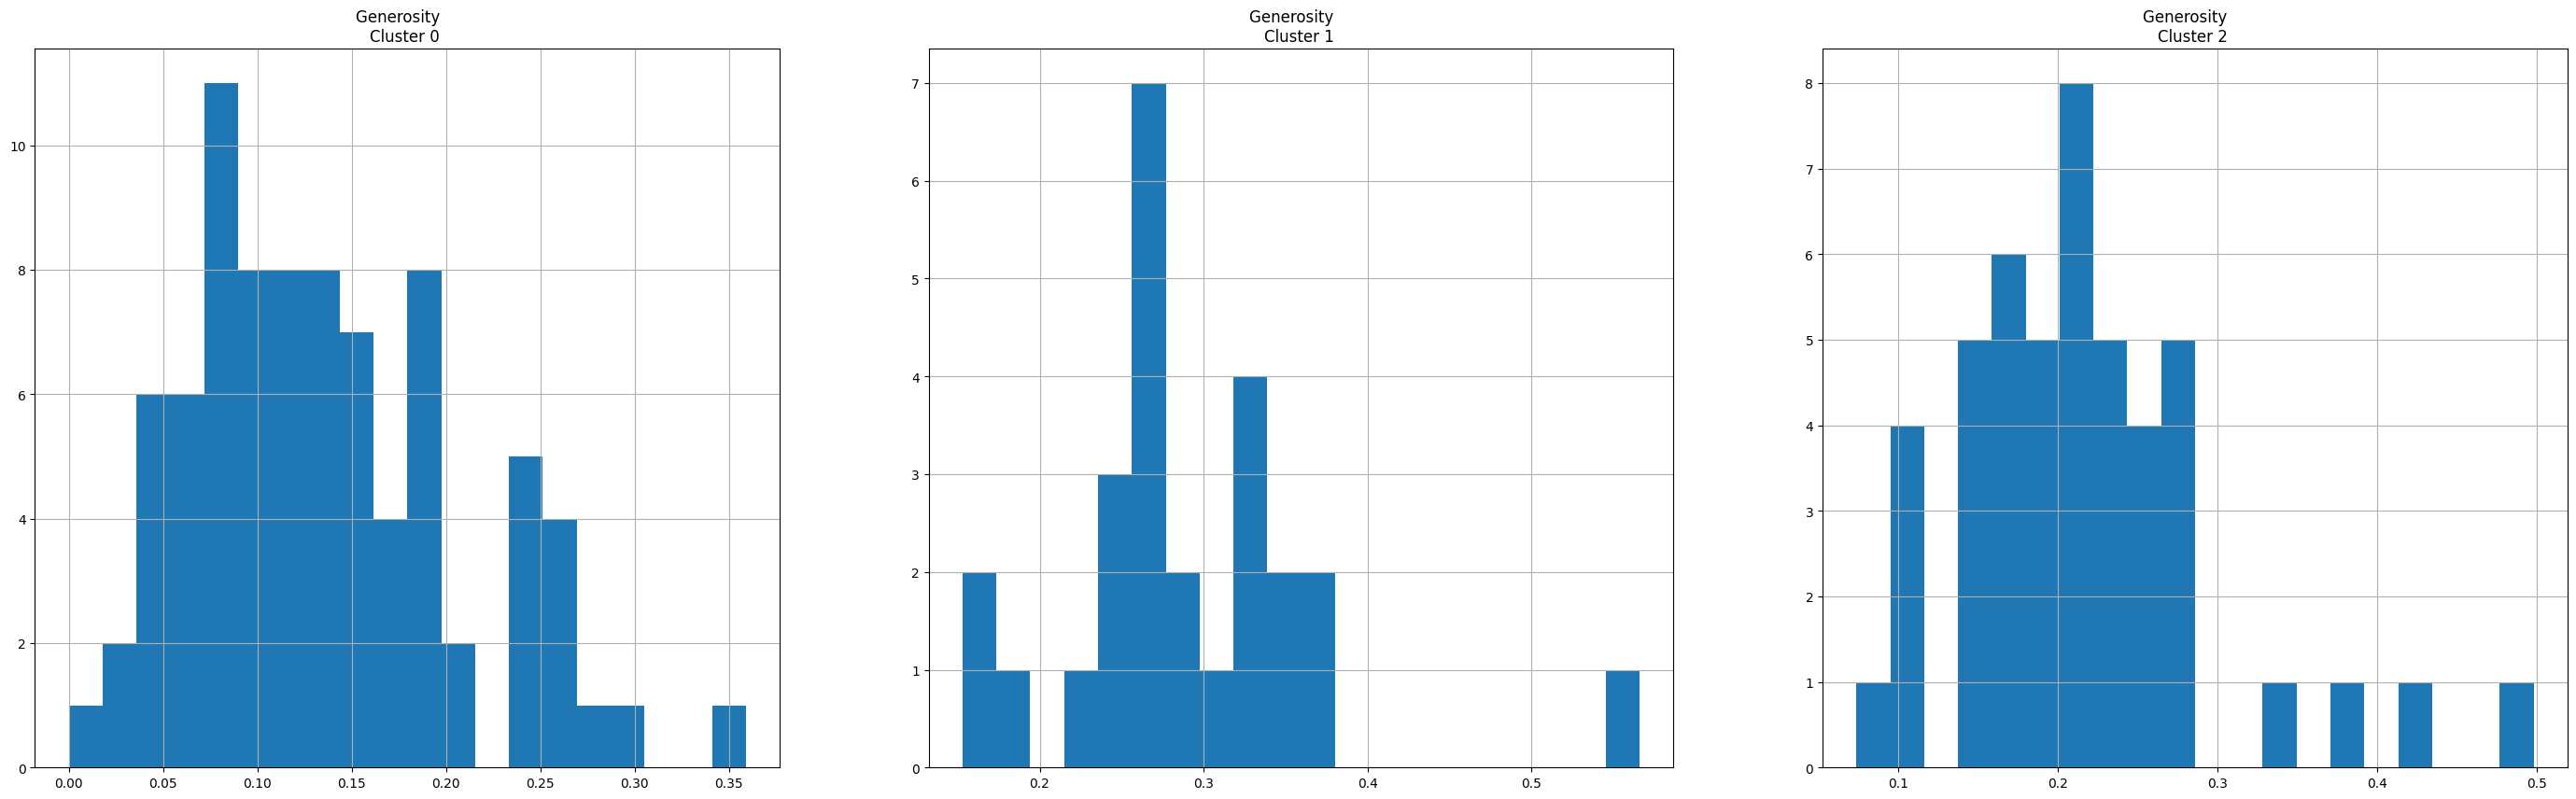

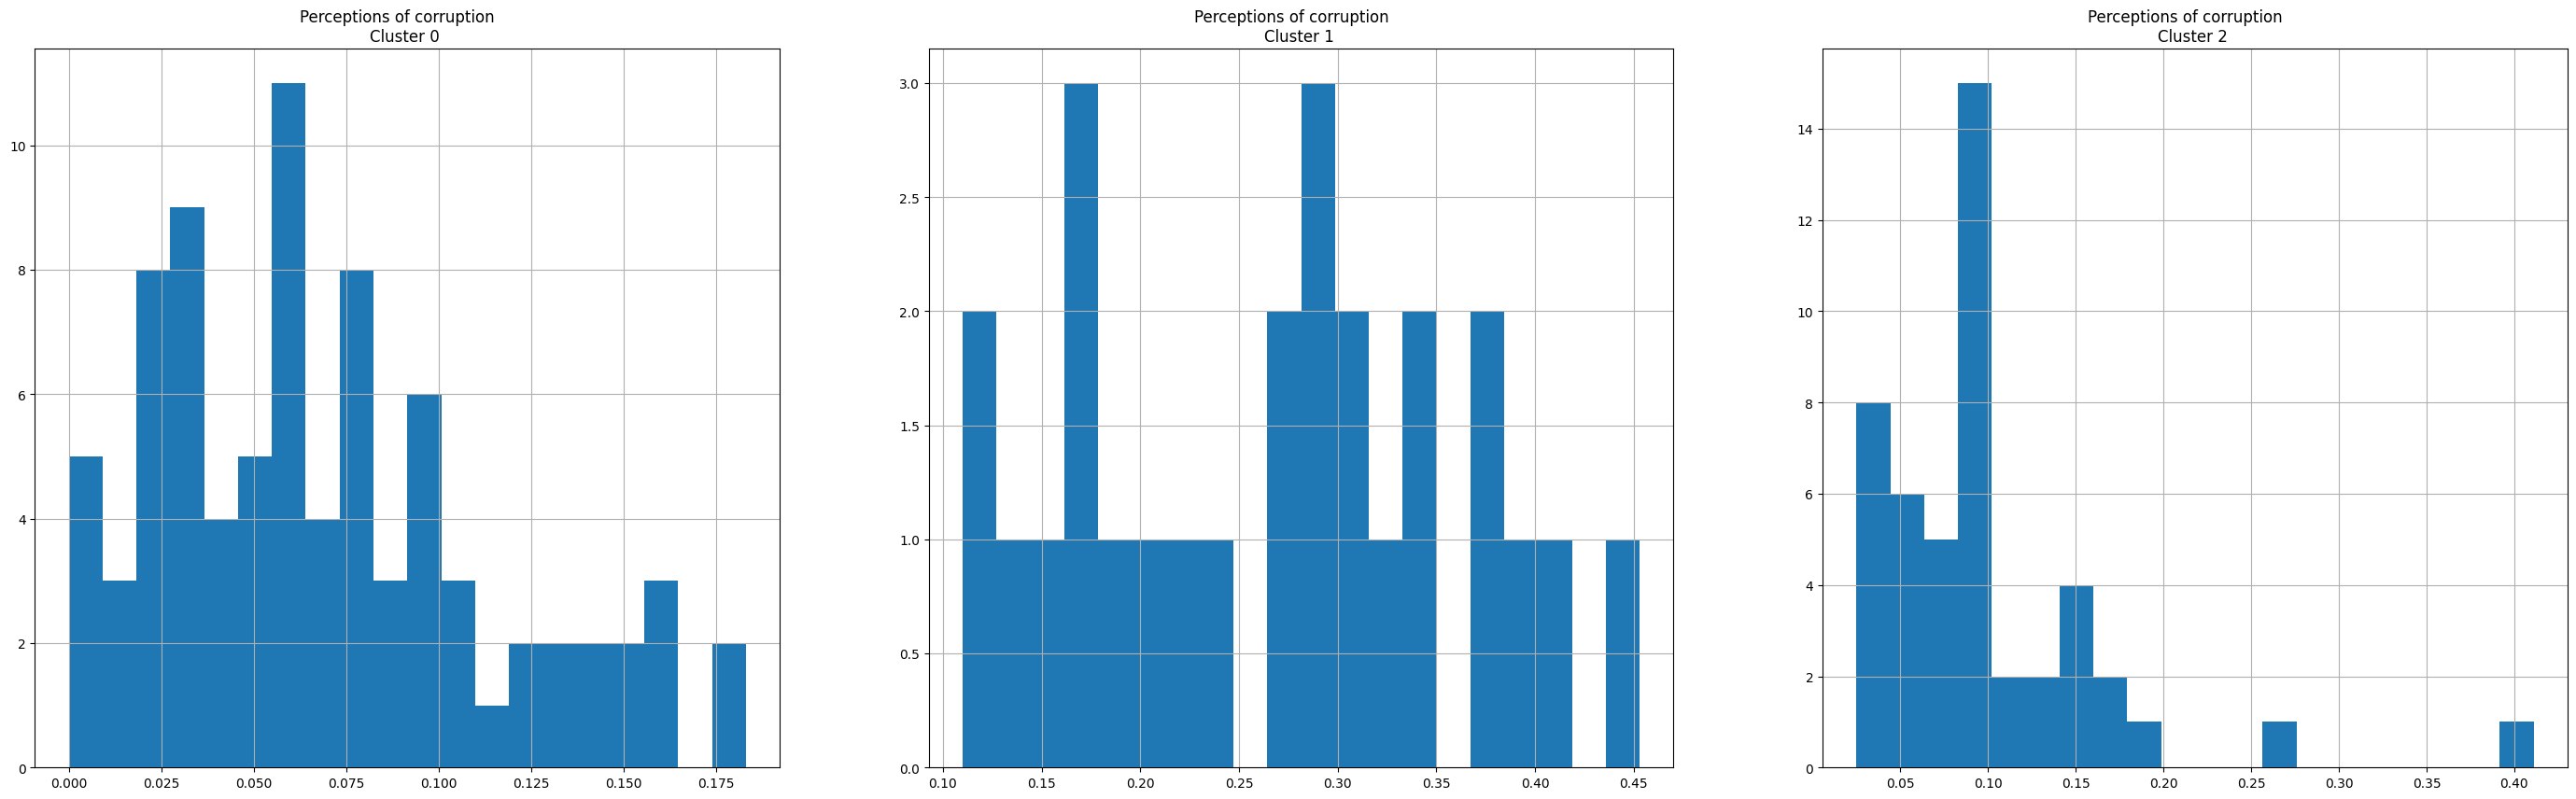

In [36]:
# Plot the histogram of various clusters
for i in df_seg.columns:
  plt.figure(figsize = (35, 10))
  for j in range(3):
    plt.subplot(1,3,j+1)
    cluster = df_cluster[df_cluster['cluster'] == j]
    cluster[i].hist(bins = 20)
    plt.title('{}    \nCluster {} '.format(i, j))
  
  plt.show()

# Visualize the Clusters

In [37]:
df_cluster

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,cluster
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,1
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,1
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,1
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,1
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,1
...,...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411,2
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147,2
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025,2
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035,2


In [38]:
# Plot the relationship between cluster and score 

fig = px.scatter(df_cluster, x = 'cluster', y = "Score",
           size = 'Overall rank', color = "Country or region", hover_name = "Country or region",
          trendline = "ols")

fig.update_layout(
    title_text = 'Happiness Score vs Cluster'
)
fig.show()

In [39]:
# Plot the relationship between cluster and GDP

fig = px.scatter(df_cluster, x='cluster', y='GDP per capita',
           size='Overall rank', color="Country or region", hover_name="Country or region",
          trendline= "ols")

fig.update_layout(
    title_text='GDP vs Clusters'
)
fig.show()

In [ ]:
import pandas as pd

# Fix for the deprecated append method in pandas
def _append(self, other, ignore_index=False, **kwargs):
    if isinstance(other, dict):
        other = pd.DataFrame([other])
    elif isinstance(other, list):
        other = pd.DataFrame(other)
    return pd.concat([self, other], ignore_index=ignore_index)
pd.DataFrame.append = _append

from bubbly.bubbly import bubbleplot

# Visaulizing the clusters with respect to economy, corruption, gdp, rank and their scores
figure = bubbleplot(dataset=df_cluster, 
    x_column='GDP per capita', y_column='Perceptions of corruption', bubble_column='Country or region',  
    color_column='cluster', z_column='Healthy life expectancy', size_column='Score',
    x_title="GDP per capita", y_title="Corruption", z_title="Life Expectancy",
    title='Clusters based Impact of Economy, Corruption and Life expectancy on Happiness Scores of Nations',
    colorbar_title='Cluster', marker_opacity=1, colorscale='Portland',
    scale_bubble=0.8, height=650)

iplot(figure, config={'scrollzoom': True})

C:\Users\edmoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\plotly\offline\offline.py:152: UserWarning: 
Unrecognized config options supplied: ['scrollzoom']
  warnings.warn(


In [48]:
from bubbly.bubbly import bubbleplot

figure = bubbleplot(dataset=df_cluster, 
    x_column='GDP per capita', y_column='Perceptions of corruption', bubble_column='Country or region',  
    color_column='cluster', z_column='Generosity', size_column='Score',
    x_title="GDP per capita", y_title="Corruption", z_title="Life Expectancy",
    title='Clusters based Impact of Economy, Corruption and Generosity on Happiness Scores of Nations',
    colorbar_title='Cluster', marker_opacity=1, colorscale='Portland',
    scale_bubble=0.8, height=650)

iplot(figure, config={'scrollzoom': True})

C:\Users\edmoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\plotly\offline\offline.py:152: UserWarning: 
Unrecognized config options supplied: ['scrollzoom']
  warnings.warn(


In [46]:
# Visualizing the clusters geographically
data = dict(type = 'choropleth', 
           locations = df_cluster["Country or region"],
           locationmode = 'country names',
           colorscale='RdYlGn',
           z = df_cluster['cluster'], 
           text = df_cluster["Country or region"],
           colorbar = {'title':'Clusters'})

layout = dict(title = 'Geographical Visualization of Clusters', 
              geo = dict(showframe = True, projection = {'type': 'azimuthal equal area'}))

choromap3 = go.Figure(data = [data], layout=layout)
iplot(choromap3)

C:\Users\edmoc\AppData\Local\Temp\ipykernel_25436\2312454836.py:13: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  choromap3 = go.Figure(data = [data], layout=layout)
